# Modelo SIR - Simulação de Epidemias com Runge-Kutta

**Disciplina**: Cálculo Numérico

**Professor**: Marcos Maia

**Autor**: Yann Keven Jordão Leão (Engenharia da Computação - UFRPE)

Este notebook tem como objetivo simular a propagação de uma epidemia utilizando o modelo SIR (Suscetíveis, Infectados e Recuperados).
O sistema de equações diferenciais será resolvido numericamente por meio do método de Runge-Kutta de ordem 4 (RK4).

A partir disso, serão respondidas perguntas como:

- Qual o dia de pico da epidemia?
- Após quantos dias a epidemia pode ser considerada controlada?

Serão também gerados gráficos para visualizar o comportamento de cada grupo populacional ao longo do tempo.


## Definição dos parâmetros e do sistema de equações diferenciais

Nesta etapa, definiremos os parâmetros do modelo fornecidos no enunciado, as condições iniciais e o vetor de tempo da simulação.

Em seguida, será implementada a função $f(y, t)$ que representa o sistema de equações diferenciais do modelo SIR:

$$
\begin{cases}
\frac{dS}{dt} = -\frac{\beta}{N} \cdot S \cdot I \\
\frac{dI}{dt} = \frac{\beta}{N} \cdot S \cdot I - \gamma \cdot I \\
\frac{dR}{dt} = \gamma \cdot I
\end{cases}
$$

Esta função recebe como entrada o vetor $y = [S, I, R]$ e retorna os valores das derivadas $[S', I', R']$ naquele instante.


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do modelo
beta = 0.4       # Taxa de transmissão
gamma = 0.035    # Taxa de recuperação
N = 1000         # População total

# Condições iniciais
S0 = 990
I0 = 10
R0 = 0

# Tempo de simulação
t0 = 0
t_end = 100
h = 0.1
t = np.arange(t0, t_end + h, h)  # vetor de tempo

# Função que representa o sistema SIR
def f(y, t):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return np.array([dSdt, dIdt, dRdt])


## Resolvendo o sistema com o método de Runge-Kutta de ordem 4 (RK4)

O método RK4 será utilizado para integrar numericamente o sistema de equações diferenciais do modelo SIR.  
Em cada iteração, os três valores $S(t)$, $I(t)$ e $R(t)$ serão atualizados simultaneamente, com base nos coeficientes $k_1$, $k_2$, $k_3$ e $k_4$, calculados para o vetor $y = [S, I, R]$.

O passo de integração utilizado será $h = 0{,}1$, e o tempo total de simulação será de 60 dias.

Abaixo, inicializamos os vetores que armazenarão os resultados e implementamos o loop principal do RK4.


In [23]:
# Inicialização dos vetores de solução
S = np.zeros(len(t))
I = np.zeros(len(t))
R = np.zeros(len(t))

# Condições iniciais
S[0] = S0
I[0] = I0
R[0] = R0

# Método de Runge-Kutta 4
for n in range(len(t) - 1):
    y = np.array([S[n], I[n], R[n]])
    k1 = f(y, t[n])
    k2 = f(y + h/2 * k1, t[n] + h/2)
    k3 = f(y + h/2 * k2, t[n] + h/2)
    k4 = f(y + h * k3, t[n] + h)

    y_next = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    S[n+1], I[n+1], R[n+1] = y_next


## Visualização dos resultados

Com os valores de $S(t)$, $I(t)$ e $R(t)$ calculados, podemos agora visualizar a evolução da epidemia ao longo do tempo.

No gráfico abaixo, cada curva representa a quantidade de indivíduos em uma das três categorias do modelo SIR:

- **Suscetíveis**: indivíduos que ainda podem ser infectados
- **Infectados**: indivíduos atualmente doentes
- **Recuperados**: indivíduos que se curaram e não podem mais ser infectados

A observação dessas curvas permite identificar o ponto de maior disseminação da doença e quando a epidemia começa a se estabilizar.


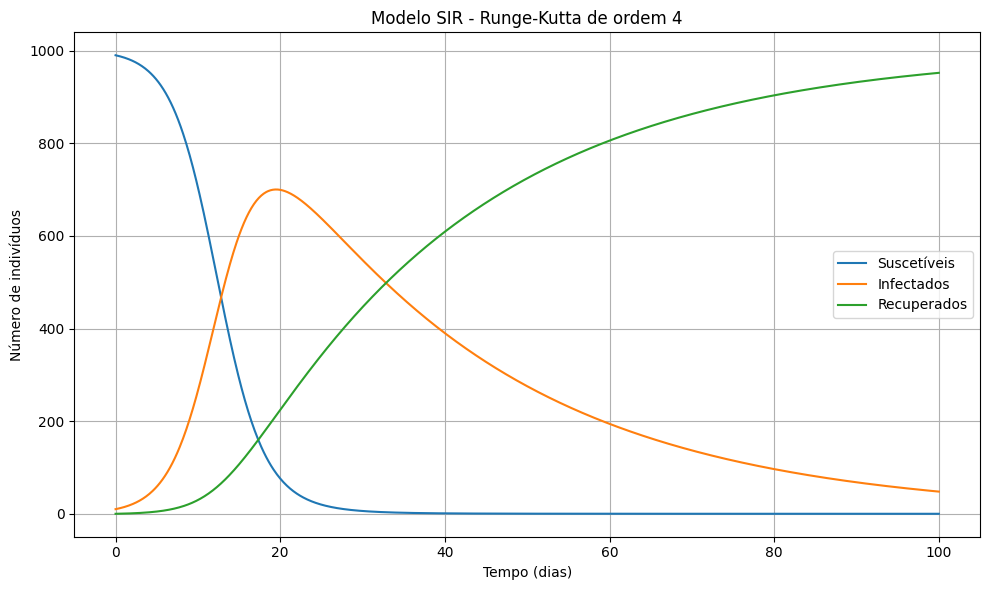

In [24]:
# Plotando os resultados
plt.figure(figsize=(10,6))
plt.plot(t, S, label='Suscetíveis')
plt.plot(t, I, label='Infectados')
plt.plot(t, R, label='Recuperados')
plt.xlabel('Tempo (dias)')
plt.ylabel('Número de indivíduos')
plt.title('Modelo SIR - Runge-Kutta de ordem 4')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Identificando o pico da epidemia e o controle

A partir dos dados gerados, é possível identificar:

- **O pico da epidemia**, que ocorre quando o número de infectados atinge seu valor máximo.
- **Quando a epidemia está controlada**, o que consideraremos como o momento em que o número de infectados cai abaixo de 1, indicando o fim da disseminação significativa da doença.

O código a seguir realiza essa análise com base nos resultados numéricos obtidos.


In [25]:
# Pico da epidemia = valor máximo de infectados
pico_dia = t[np.argmax(I)]
pico_valor = np.max(I)

# Epidemia controlada, quando infectados < 10
controlada_dia = next((t[i] for i in range(len(I)) if I[i] < 10 and t[i] > pico_dia), None)

In [26]:
# Resultados
print(f"Pico da epidemia: {pico_valor:.0f} infectados no dia {pico_dia:.0f}")
if controlada_dia is not None:
    print(f"Epidemia controlada aproximadamente no dia {controlada_dia:.0f}")
else:
    print("A epidemia não foi controlada durante o período simulado.")

Pico da epidemia: 700 infectados no dia 20
A epidemia não foi controlada durante o período simulado.


>**Observação**: ao final de 60 dias, a epidemia ainda não foi controlada. O número de infectados permanece acima de 10, indicando que a simulação pode ser estendida para visualizar a estabilização completa do sistema.


## Conclusão

Com base na minha simulação, observamos que o número de infectados atinge seu pico por volta do dia 20, com aproximadamente 700 pessoas infectadas. No entanto, até o final do período simulado (60 dias), a epidemia **ainda não foi considerada controlada**, já que o número de infectados **permanece acima de 10**.

Algo que pode-se fazer é aumentar o número de dias, alterando a variáveel $t_end$, para 90 ou 120 dias (3 ou 4 meses).